## Laboratorio 3: Análisis de datos.

En este notebook, vamos a aplicar técnicas de Analítica de Datos para realizar un análisis completo sobre una base de datos orientada a clasificación, integrando SQL para la extracción y manipulación de datos, Análisis Exploratorio de Datos (EDA) para la comprensión de patrones y relaciones, técnicas de imputación de datos para el tratamiento de valores ausentes, y visualización interactiva mediante Streamlit para la presentación de resultados, con el fin de desarrollar y evaluar modelos predictivos que permitan asignar cada instancia a una categoría o clase predefinida.

## Primero empecemos con el EDA.

In [1]:
# Veamos las primeras filas del dataset para entender su estructura y contenido. 
import pandas as pd

df = pd.read_csv('../data/raw/dataset_clasificacion.csv')

df.head()

,Customer_ID,Customer_Name,Gender,Age,State,City,Bank_Branch,Account_Type,Transaction_ID,Transaction_Date,...,Merchant_Category,Account_Balance,Transaction_Device,Transaction_Location,Device_Type,Is_Fraud,Transaction_Currency,Customer_Contact,Transaction_Description,Customer_Email
0,d5f6ec07-d69e-4f47-b9b4-7c58ff17c19e,Osha Tella,Male,60,Kerala,Thiruvananthapuram,Thiruvananthapuram Branch,Savings,4fa3208f-9e23-42dc-b330-844829d0c12c,23-01-2025,...,Restaurant,74557.27,Voice Assistant,"Thiruvananthapuram, Kerala",POS,0,INR,+9198579XXXXXX,Bitcoin transaction,oshaXXXXX@XXXXX.com
1,7c14ad51-781a-4db9-b7bd-67439c175262,Hredhaan Khosla,Female,51,Maharashtra,Nashik,Nashik Branch,Business,c9de0c06-2c4c-40a9-97ed-3c7b8f97c79c,11-01-2025,...,Restaurant,74622.66,POS Mobile Device,"Nashik, Maharashtra",Desktop,0,INR,+9191074XXXXXX,Grocery delivery,hredhaanXXXX@XXXXXX.com
2,3a73a0e5-d4da-45aa-85f3-528413900a35,Ekani Nazareth,Male,20,Bihar,Bhagalpur,Bhagalpur Branch,Savings,e41c55f9-c016-4ff3-872b-cae72467c75c,25-01-2025,...,Groceries,66817.99,ATM,"Bhagalpur, Bihar",Desktop,0,INR,+9197745XXXXXX,Mutual fund investment,ekaniXXX@XXXXXX.com
3,7902f4ef-9050-4a79-857d-9c2ea3181940,Yamini Ramachandran,Female,57,Tamil Nadu,Chennai,Chennai Branch,Business,7f7ee11b-ff2c-45a3-802a-49bc47c02ecb,19-01-2025,...,Entertainment,58177.08,POS Mobile App,"Chennai, Tamil Nadu",Mobile,0,INR,+9195889XXXXXX,Food delivery,yaminiXXXXX@XXXXXXX.com
4,3a4bba70-d9a9-4c5f-8b92-1735fd8c19e9,Kritika Rege,Female,43,Punjab,Amritsar,Amritsar Branch,Savings,f8e6ac6f-81a1-4985-bf12-f60967d852ef,30-01-2025,...,Entertainment,16108.56,Virtual Card,"Amritsar, Punjab",Mobile,0,INR,+9195316XXXXXX,Debt repayment,kritikaXXXX@XXXXXX.com


In [2]:
# Veamos la información general del dataset: filas, columnas, tipos de datos, valores nulos.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Customer_ID              200000 non-null  object 
 1   Customer_Name            200000 non-null  object 
 2   Gender                   200000 non-null  object 
 3   Age                      200000 non-null  int64  
 4   State                    200000 non-null  object 
 5   City                     200000 non-null  object 
 6   Bank_Branch              200000 non-null  object 
 7   Account_Type             200000 non-null  object 
 8   Transaction_ID           200000 non-null  object 
 9   Transaction_Date         200000 non-null  object 
 10  Transaction_Time         200000 non-null  object 
 11  Transaction_Amount       200000 non-null  float64
 12  Merchant_ID              200000 non-null  object 
 13  Transaction_Type         200000 non-null  object 
 14  Merc

Aquí podemos ver que tenemos 24 variables en total, de las cuales 3 son numéricas (Age, Transaction_Amount, Account_Balance) y el resto son categóricas. Cabe destacar que la variable Is_Fraud, aunque es numérica binaria (0 y 1), se considera nuestra variable objetivo y se trata como categórica para efectos del análisis de clasificación.

In [3]:
# Nos dimos cuenta que nuestras variables númericas son Age, Transaction_Amount y Account_Balance. Veamos estadísticas descriptivas básicas para estas columnas: primero contamos el número de transacciones totales, luego la media, la desviación estándar, el mínimo, 25%, 50%, 75% y máximo percentiles.
df.describe()

,Age,Transaction_Amount,Account_Balance,Is_Fraud
count,200000.000000,200000.000000,200000.000000,200000.000000
mean,44.015110,49538.015554,52437.988784,0.050440
std,15.288774,28551.874004,27399.507128,0.218852
min,18.000000,10.290000,5000.820000,0.000000
25%,31.000000,24851.345000,28742.395000,0.000000
50%,44.000000,49502.440000,52372.555000,0.000000
75%,57.000000,74314.625000,76147.670000,0.000000
max,70.000000,98999.980000,99999.950000,1.000000


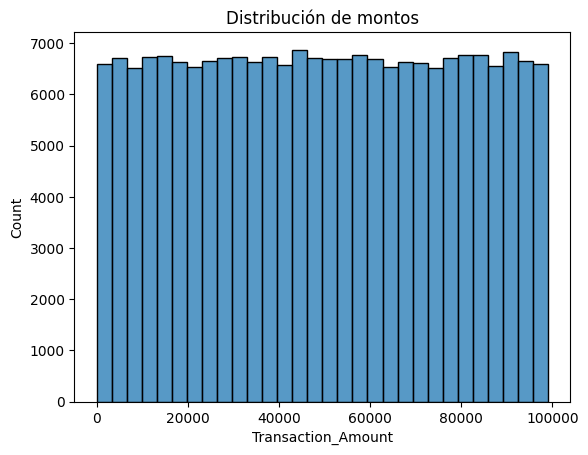

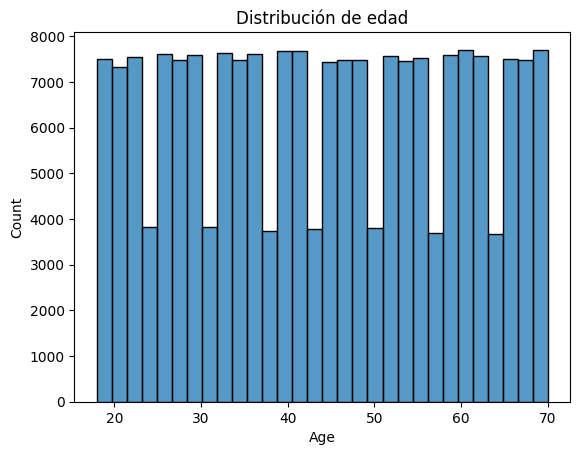

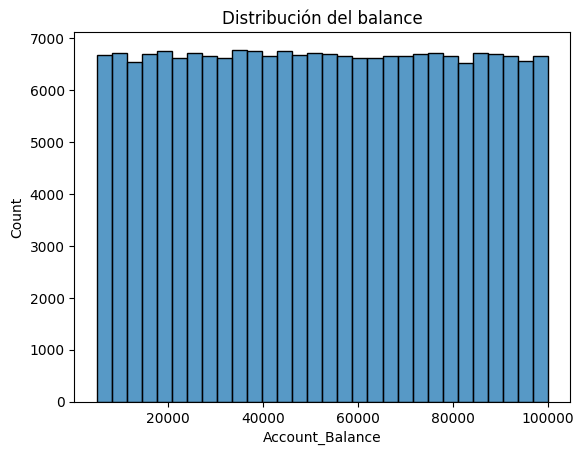

In [4]:
# Histogramas para visualizar la distribución de las variables numéricas: Transaction_Amount, Age, Account_Balance. Esto nos ayudará a entender la forma de la distribución, detectar posibles sesgos o valores atípicos.
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Transaction_Amount'], bins=30)
plt.title("Distribución de montos")
plt.show()

sns.histplot(df['Age'], bins=30)
plt.title("Distribución de edad")
plt.show()

sns.histplot(df['Account_Balance'], bins=30)
plt.title("Distribución del balance")
plt.show()

El análisis conjunto de los histogramas revela que el dataset presenta una distribución uniforme, donde todas las variables operan bajo una probabilidad casi idéntica en todo su rango.

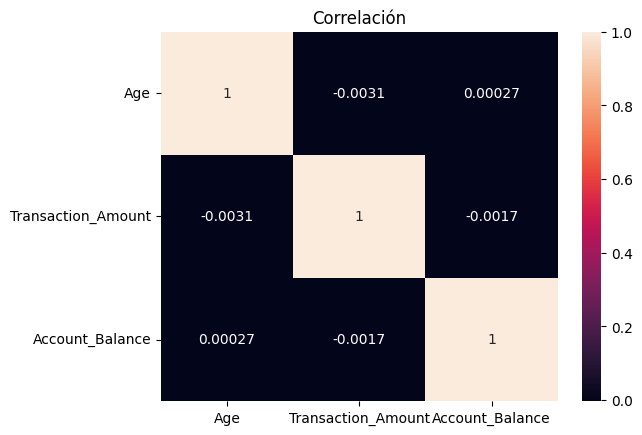

In [5]:
# Matriz de correlación para las variables numéricas. Esto nos ayudará a identificar si hay relaciones lineales entre las variables, lo cual puede ser útil para la selección de características y la interpretación del modelo.
sns.heatmap(
    df[['Age','Transaction_Amount','Account_Balance']].corr(),
    annot=True
)
plt.title("Correlación")
plt.show()

* **Independencia Total:** Los valores son cercanos a cero (**-0.0031**, **-0.0017** y **0.00027**), por lo tanto, **no existe ninguna relación lineal** entre la edad, el monto de la transacción y el balance de la cuenta. 


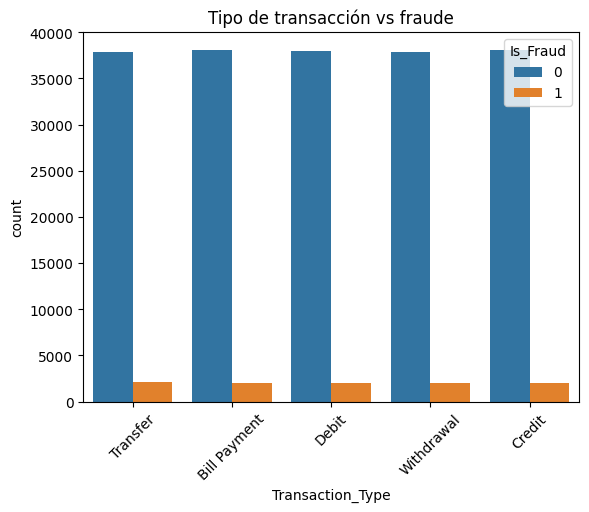

In [6]:
# Gráficos de barras para comparar la cantidad de transacciones fraudulentas vs no fraudulentas por tipo de transacción. Esto nos permitirá identificar si ciertos tipos de transacciones tienen una mayor proporción de fraude.
sns.countplot(x='Transaction_Type', hue='Is_Fraud', data=df)
plt.xticks(rotation=45)
plt.title("Tipo de transacción vs fraude")
plt.show()

Las transacciones normales (azul) superan masivamente a las fraudulentas (naranja). 

El fraude se reparte de forma casi idéntica entre Transferencias, Pagos, Débito, Retiros y Crédito, donde el tipo de transacción no es un factor determinante para el fraude.

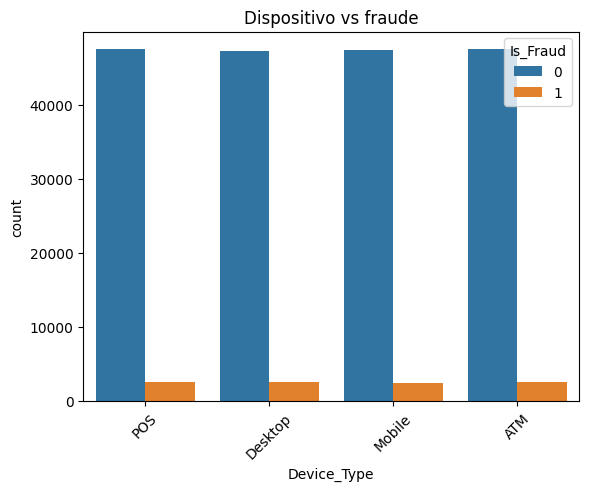

In [7]:
# Gráficos de barras para comparar la cantidad de transacciones fraudulentas vs no fraudulentas por tipo de dispositivo. Esto nos permitirá identificar si ciertos tipos de dispositivos tienen una mayor proporción de fraude.
sns.countplot(x='Device_Type', hue='Is_Fraud', data=df)
plt.xticks(rotation=45)
plt.title("Dispositivo vs fraude")
plt.show()

El fraude se reparte de forma idéntica según el dispositivo en que se haga la transacción. Esto sugiere que el tipo de dispositivo no es un factor determinante para el fraude en este dataset.

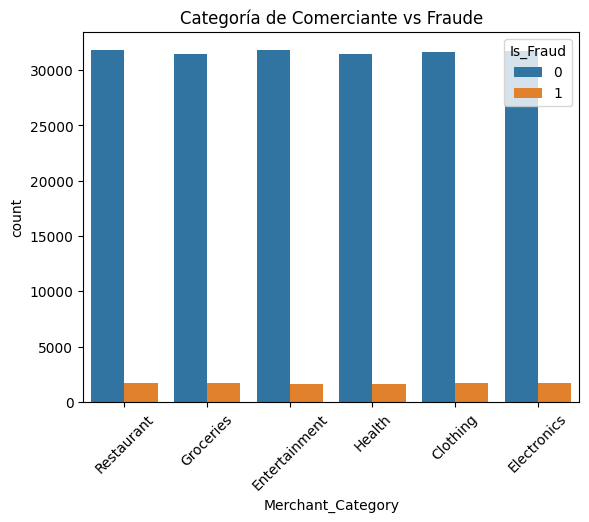

In [8]:
# Gráficos de barras para comparar la cantidad de transacciones fraudulentas vs no fraudulentas por categoría de comerciante. Esto nos permitirá identificar si ciertas categorías tienen una mayor proporción de fraude.
sns.countplot(x='Merchant_Category', hue='Is_Fraud', data=df)
plt.xticks(rotation=45)
plt.title("Categoría de Comerciante vs Fraude")
plt.show()

El fraude se reparte de manera idéntica entre las categorías de comercio, por lo que no se observa una categoría con mayor proporción de fraude. Esto sugiere que el tipo de comercio no es un factor determinante para el fraude en este dataset.

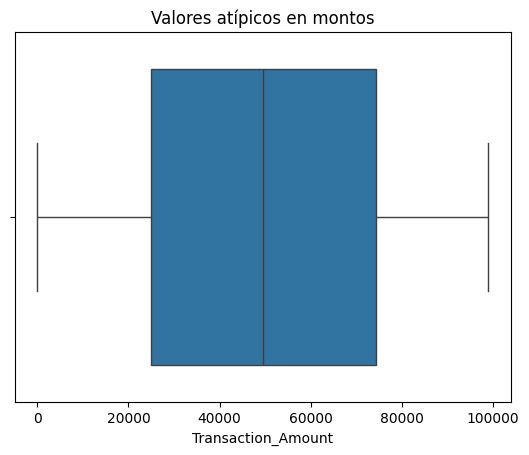

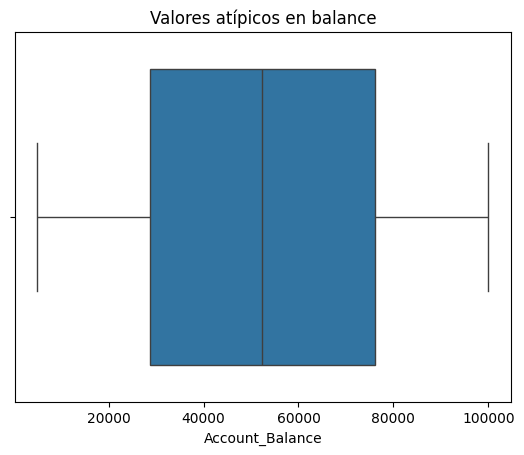

In [9]:
# Boxplots para detectar outliers en las variables numéricas. Esto nos permitirá identificar si hay valores atípicos que podrían afectar el rendimiento del modelo o requerir tratamiento especial.

sns.boxplot(x=df['Transaction_Amount'])
plt.title("Valores atípicos en montos")
plt.show()

sns.boxplot(x=df['Account_Balance'])
plt.title("Valores atípicos en balance")
plt.show()

El diagrama de caja para Transaction_Amount muestra una distribución simétrica con una mediana de 50,000. No se detectan valores atípicos, lo que indica que todos los montos de las transacciones, incluso los fraudulentos, se mantienen dentro del rango predefinido de 0 a 100,000. Esto sugiere que el fraude no puede ser detectado simplemente buscando 'compras inusualmente grandes. 

Lo mismo pasa en Account_Balance donde las anomalías (fraude) no dependen de valores extremos en el saldo.

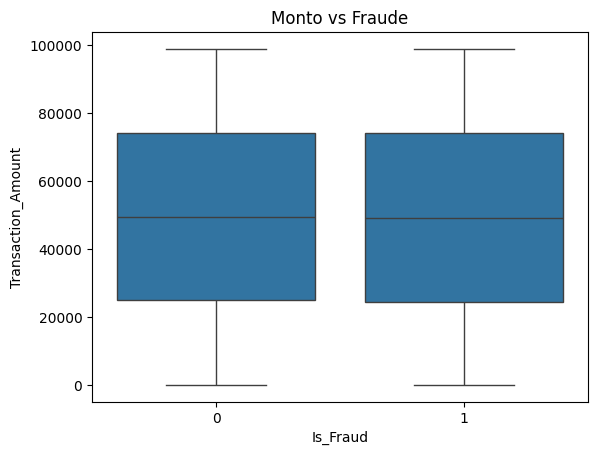

In [10]:
# Boxplot para comparar la distribución de los montos entre transacciones fraudulentas y no fraudulentas. Esto nos ayudará a identificar si hay diferencias significativas en los montos entre ambos grupos, lo cual podría ser un indicador importante para el modelo de clasificación.
sns.boxplot(x='Is_Fraud', y='Transaction_Amount', data=df)
plt.title("Monto vs Fraude")
plt.show()

Al realizar la comparación bivariada entre Transaction_Amount e Is_Fraud, se observa que no hay una diferencia significativa en las distribuciones de ambos grupos. El comportamiento del monto en las transacciones fraudulentas mimetiza perfectamente al de las transacciones legítimas. Por lo tanto, el modelo de detección no podrá apoyarse en umbrales de monto simples para identificar el fraude, confirmando la necesidad de algoritmos de clasificación más complejos.

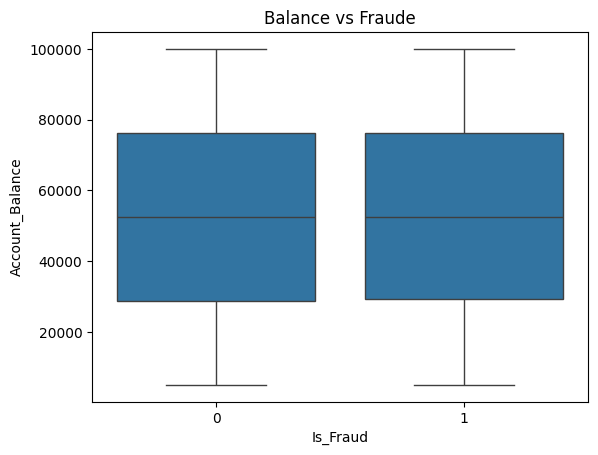

In [11]:
# Boxplot para comparar la distribución del balance entre transacciones fraudulentas y no fraudulentas. Esto nos ayudará a identificar si hay diferencias significativas en el balance entre ambos grupos, lo cual podría ser un indicador importante para el modelo de clasificación.
sns.boxplot(x='Is_Fraud', y='Account_Balance', data=df)
plt.title("Balance vs Fraude")
plt.show()

Al igual que en el anterior, se puede camuflar las transacciones fraudulentas.

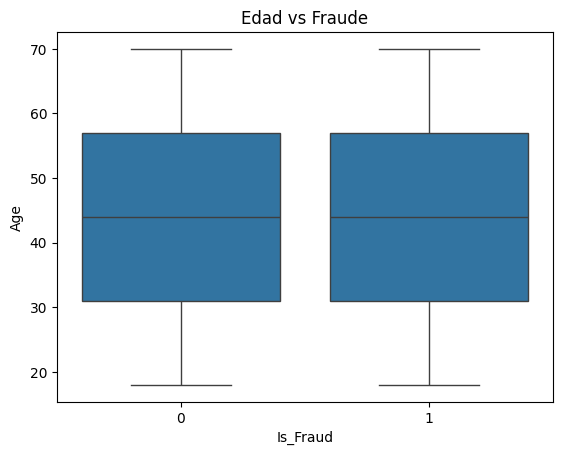

In [12]:
# Boxplot para comparar la distribución de la edad entre transacciones fraudulentas y no fraudulentas. Esto nos ayudará a identificar si hay diferencias significativas en la edad entre ambos grupos, lo cual podría ser un indicador importante para el modelo de clasificación.
sns.boxplot(x='Is_Fraud', y='Age', data=df)
plt.title("Edad vs Fraude")
plt.show()

Tampoco se muestra diferencia entre las transacciones fraudulentas y la edad.

## Resumen primera parte 
Durante el análisis exploratorio no se identificaron valores faltantes, las distribuciones de las variables numéricas presentan un comportamiento estable, sin evidencia significativa de valores atípicos extremos que afecten el análisis.

A partir de los boxplots y las visualizaciones realizadas, no se observaron diferencias marcadas entre las transacciones fraudulentas y no fraudulentas en las variables analizadas, lo que sugiere que estas características, de forma individual, no permiten discriminar claramente entre ambos tipos de transacciones.

En general, el dataset presenta un comportamiento homogéneo y bien estructurado, lo cual facilita su análisis, aunque también indica que podrían requerirse técnicas más avanzadas o el análisis conjunto de variables para identificar patrones de fraude.

## 2) Veamos ahora el tratamiento de datos faltantes.

In [12]:
# Verifiquemos si hay valores nulos en el dataset, ya que esto podría afectar el rendimiento del modelo de clasificación. Si encontramos valores nulos, deberíamos considerar cómo manejarlos.
df.isnull().sum()

Customer_ID                0
Customer_Name              0
Gender                     0
Age                        0
State                      0
City                       0
Bank_Branch                0
Account_Type               0
Transaction_ID             0
Transaction_Date           0
Transaction_Time           0
Transaction_Amount         0
Merchant_ID                0
Transaction_Type           0
Merchant_Category          0
Account_Balance            0
Transaction_Device         0
Transaction_Location       0
Device_Type                0
Is_Fraud                   0
Transaction_Currency       0
Customer_Contact           0
Transaction_Description    0
Customer_Email             0
dtype: int64

Cómo nuestro dataset no tiene datos faltantes, vamos a eliminar algunos valores para simular que proceso de imputación sería mejor.

In [13]:
# Para simular un escenario realista, vamos a eliminar algunos valores de las variables numéricas para crear un dataset con valores faltantes. Esto nos permitirá practicar técnicas de imputación y manejo de datos faltantes en el futuro.
import numpy as np

df_missing = df.copy()

indices_age = df_missing.sample(n=2201, random_state=42).index
df_missing.loc[indices_age, 'Age'] = np.nan

indices_amount = df_missing.sample(n=1495, random_state=1).index
df_missing.loc[indices_amount, 'Transaction_Amount'] = np.nan

indices_balance = df_missing.sample(n=2149, random_state=7).index
df_missing.loc[indices_balance, 'Account_Balance'] = np.nan

In [14]:
# Verifiquemos nuevamente si hay valores nulos en el dataset después de eliminar algunos valores. Esto nos permitirá confirmar que hemos creado un escenario con datos faltantes para practicar técnicas de imputación.
df_missing.isnull().sum()

Customer_ID                   0
Customer_Name                 0
Gender                        0
Age                        2201
State                         0
City                          0
Bank_Branch                   0
Account_Type                  0
Transaction_ID                0
Transaction_Date              0
Transaction_Time              0
Transaction_Amount         1495
Merchant_ID                   0
Transaction_Type              0
Merchant_Category             0
Account_Balance            2149
Transaction_Device            0
Transaction_Location          0
Device_Type                   0
Is_Fraud                      0
Transaction_Currency          0
Customer_Contact              0
Transaction_Description       0
Customer_Email                0
dtype: int64

In [15]:
# Ahora que tenemos un dataset con valores faltantes, vamos a crear una copia del dataset original para aplicar técnicas de imputación. En este caso, utilizaremos la media para imputar los valores faltantes en las variables numéricas: Transaction_Amount, Age y Account_Balance.
df_mean = df_missing.copy()
df_mean['Transaction_Amount'] = df_mean['Transaction_Amount'].fillna(
    df_mean['Transaction_Amount'].mean()
)

df_mean['Age'] = df_mean['Age'].fillna(
    df_mean['Age'].mean()
)
df_mean['Account_Balance'] = df_mean['Account_Balance'].fillna(
    df_mean['Account_Balance'].mean()
)

In [16]:
# Ahora vamos a aplicar una técnica de imputación más avanzada utilizando KNNImputer de la biblioteca sklearn. Esta técnica utiliza los valores de los vecinos más cercanos para imputar los valores faltantes, lo que puede ser más efectivo que la imputación por media en algunos casos.
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)

df_knn = df_missing.copy()

df_knn[['Transaction_Amount','Age','Account_Balance']] = imputer.fit_transform(
    df_knn[['Transaction_Amount','Age','Account_Balance']]
)

In [25]:
# Finalmente, comparemos las estadísticas descriptivas de las variables numéricas después de aplicar ambas técnicas de imputación (media y KNN) para ver cómo han cambiado los valores y si hay diferencias significativas entre ambos métodos.
print("BASE SIN IMPUTACIÓN")
print(df_missing[['Transaction_Amount','Age','Account_Balance']].describe())
print("MEAN")
print(df_mean[['Transaction_Amount','Age','Account_Balance']].describe())

BASE SIN IMPUTACIÓN
       Transaction_Amount            Age  Account_Balance
count       198505.000000  197799.000000    197851.000000
mean         49542.927064      44.015910     52432.206626
std          28554.074125      15.287741     27397.347438
min             10.290000      18.000000      5000.820000
25%          24850.790000      31.000000     28744.620000
50%          49510.640000      44.000000     52363.750000
75%          74320.880000      57.000000     76131.265000
max          98999.980000      70.000000     99999.950000
MEAN
       Transaction_Amount            Age  Account_Balance
count       200000.000000  200000.000000    200000.000000
mean         49542.927064      44.015910     52432.206626
std          28447.152553      15.203387     27249.756915
min             10.290000      18.000000      5000.820000
25%          25045.767500      31.000000     29009.812500
50%          49542.927064      44.000000     52432.206626
75%          74137.485000      57.000000     75

In [26]:
# Comparación de estadísticas descriptivas después de aplicar KNNImputer
print("BASE SIN IMPUTACIÓN")
print(df_missing[['Transaction_Amount','Age','Account_Balance']].describe())
print("\nKNN")
print(df_knn[['Transaction_Amount','Age','Account_Balance']].describe())

BASE SIN IMPUTACIÓN
       Transaction_Amount            Age  Account_Balance
count       198505.000000  197799.000000    197851.000000
mean         49542.927064      44.015910     52432.206626
std          28554.074125      15.287741     27397.347438
min             10.290000      18.000000      5000.820000
25%          24850.790000      31.000000     28744.620000
50%          49510.640000      44.000000     52363.750000
75%          74320.880000      57.000000     76131.265000
max          98999.980000      70.000000     99999.950000

KNN
       Transaction_Amount            Age  Account_Balance
count       200000.000000  200000.000000    200000.000000
mean         49560.215454      44.016418     52464.229499
std          28480.211461      15.230970     27300.003909
min             10.290000      18.000000      5000.820000
25%          25006.100000      31.000000     28948.472500
50%          49556.175000      44.000000     52430.230000
75%          74206.382500      57.000000     75

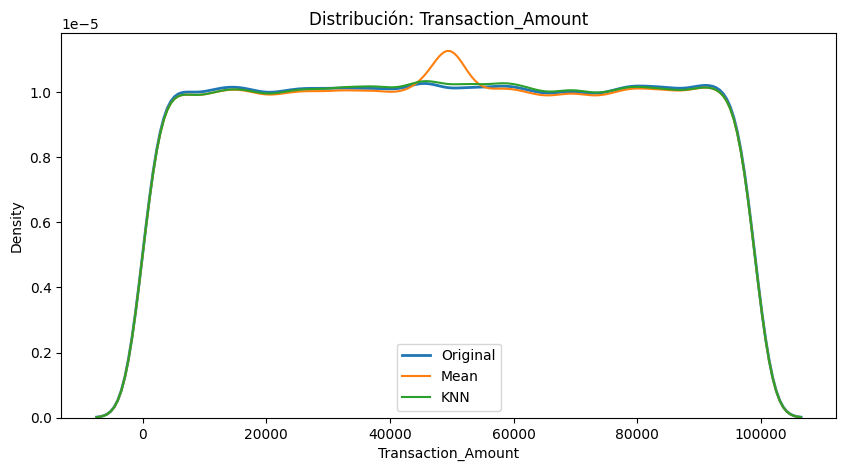

In [27]:
# Para visualizar mejor las diferencias entre las distribuciones de las variables numéricas después de aplicar ambas técnicas de imputación, vamos a crear gráficos de densidad (KDE) para cada variable. Esto nos permitirá comparar visualmente cómo se han modificado las distribuciones con cada método de imputación.
import seaborn as sns
import matplotlib.pyplot as plt

col = 'Transaction_Amount'

plt.figure(figsize=(10,5))

# Original (sin tocar)
sns.kdeplot(df[col], label="Original", linewidth=2)

# Mean imputado
sns.kdeplot(df_mean[col], label="Mean")

# KNN imputado
sns.kdeplot(df_knn[col], label="KNN")

plt.legend()
plt.title(f"Distribución: {col}")
plt.show()

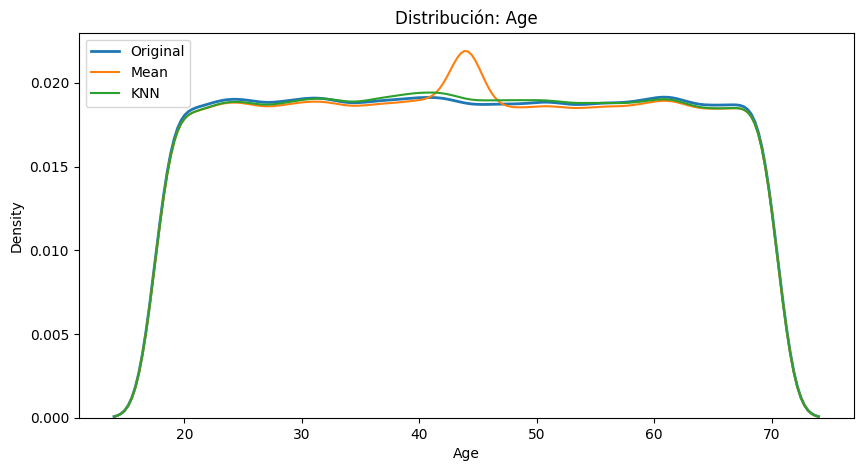

In [28]:
# Repetimos el mismo proceso para la variable Age, comparando las distribuciones original, imputada por media y imputada por KNN.
import seaborn as sns
import matplotlib.pyplot as plt

col = 'Age'

plt.figure(figsize=(10,5))

# Original (sin tocar)
sns.kdeplot(df[col], label="Original", linewidth=2)

# Mean imputado
sns.kdeplot(df_mean[col], label="Mean")

# KNN imputado
sns.kdeplot(df_knn[col], label="KNN")

plt.legend()
plt.title(f"Distribución: {col}")
plt.show()

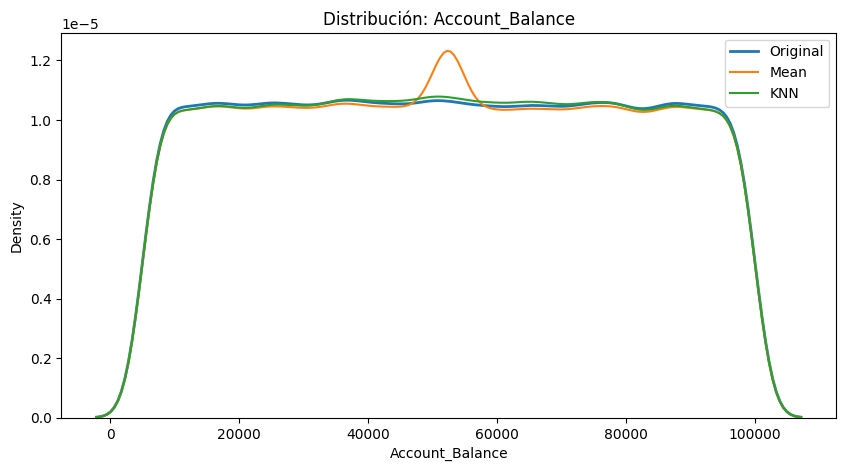

In [24]:
# Finalmente, repetimos el mismo proceso para la variable Account_Balance, comparando las distribuciones original, imputada por media y imputada por KNN.
import seaborn as sns
import matplotlib.pyplot as plt

col = 'Account_Balance'

plt.figure(figsize=(10,5))

# Original (sin tocar)
sns.kdeplot(df[col], label="Original", linewidth=2)

# Mean imputado
sns.kdeplot(df_mean[col], label="Mean")

# KNN imputado
sns.kdeplot(df_knn[col], label="KNN")

plt.legend()
plt.title(f"Distribución: {col}")
plt.show()

## Resumen Segunda parte 
La imputación por la media genera una acumulación artificial de valores alrededor del promedio, lo cual se evidencia en el pico pronunciado en la distribución. En contraste, el método KNN produce una distribución más suave y realista, preservando mejor la variabilidad de los datos originales.

## 3) Pruebas de asociación y dependencia

In [30]:
# Realizamos chi-cuadrado para evaluar la asociación entre la variable categórica Gender y la variable objetivo Is_Fraud. Esto nos permitirá identificar si hay una relación significativa entre el género y la probabilidad de que una transacción sea fraudulenta, lo cual podría ser útil para la selección de características y la interpretación del modelo de clasificación.  
from scipy.stats import chi2_contingency
import pandas as pd

tabla = pd.crosstab(df['Gender'], df['Is_Fraud'])

chi2, p, dof, expected = chi2_contingency(tabla)

print("p-value:", p)

p-value: 0.7794929726786605


Se realizó una prueba de Chi-cuadrado de independencia para evaluar la relación entre Gender e Is_Fraud. El p-value obtenido de 0.7794 indica que no hay evidencia suficiente para rechazar la hipótesis nula de independencia. Por lo tanto, el género y la presencia de fraude son variables independientes en esta muestra.

In [31]:
# Chi -cuadrado para evaluar la asociación entre la variable categórica Device_Type y la variable objetivo Is_Fraud. Esto nos permitirá identificar si hay una relación significativa entre el tipo de dispositivo y la probabilidad de que una transacción sea fraudulenta, lo cual podría ser útil para la selección de características y la interpretación del modelo de clasificación.
from scipy.stats import chi2_contingency
import pandas as pd

tabla = pd.crosstab(df['Device_Type'], df['Is_Fraud'])

chi2, p, dof, expected = chi2_contingency(tabla)

print("p-value:", p)

p-value: 0.8786413453183752


Al igual que en el primer paso, el tipo de dispositivo y la presencia de fraude son variables independientes ya que el valor p esde 0.8786.

In [34]:
# Chi -cuadrado para evaluar la asociación entre la variable categórica Merchant_Category y la variable objetivo Is_Fraud. Esto nos permitirá identificar si hay una relación significativa entre la categoría del comerciante y la probabilidad de que una transacción sea fraudulenta, lo cual podría ser útil para la selección de características y la interpretación del modelo de clasificación.
from scipy.stats import chi2_contingency
import pandas as pd

tabla_tt = pd.crosstab(df['Merchant_Category'], df['Is_Fraud'])

chi2, p, dof, expected = chi2_contingency(tabla_tt)

print("p-value:", p)

p-value: 0.2342918267877535


Como p>0.05, no podemos rechazar la hipótesis nula, lo que sugiere que no hay una asociación significativa entre la categoría del comerciante y la probabilidad de que una transacción sea fraudulenta. Esto implica que la variable Merchant_Category podría no ser un predictor útil para el modelo de clasificación de fraude.

In [35]:
# Chi -cuadrado para evaluar la asociación entre la variable categórica Transaction_Type y la variable objetivo Is_Fraud. Esto nos permitirá identificar si hay una relación significativa entre el tipo de transacción y la probabilidad de que una transacción sea fraudulenta, lo cual podría ser útil para la selección de características y la interpretación del modelo de clasificación.
from scipy.stats import chi2_contingency
import pandas as pd

tabla = pd.crosstab(df['Transaction_Type'], df['Is_Fraud'])

chi2, p, dof, expected = chi2_contingency(tabla)

print("p-value:", p)

p-value: 0.36949239454344807


Como p>0.05, no podemos rechazar la hipótesis nula, lo que sugiere que no hay una asociación significativa entre el tipo de transacción y la probabilidad de que una transacción sea fraudulenta. Esto implica que la variable Transaction_Type podría no ser un predictor útil para el modelo de clasificación de fraude.

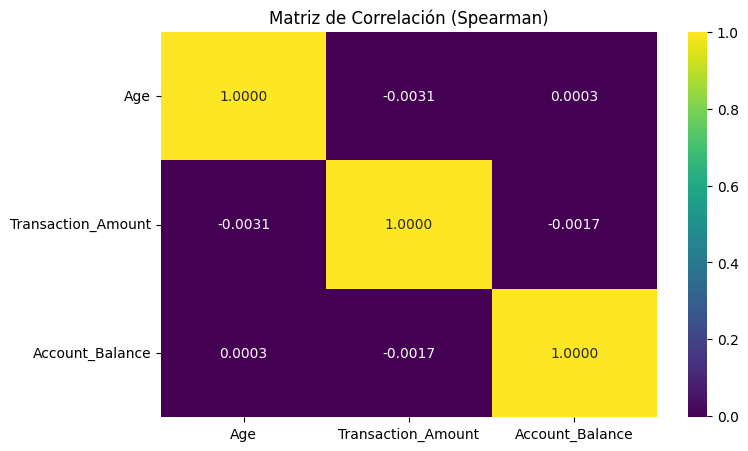

In [38]:
# Matriz de correlación de Spearman
corr_spearman = df[['Age', 'Transaction_Amount', 'Account_Balance']].corr(method='spearman')

# Visualización
plt.figure(figsize=(8,5))
sns.heatmap(corr_spearman, annot=True, cmap='viridis', fmt=".4f")
plt.title("Matriz de Correlación (Spearman)")
plt.show()

Se calcularon los coeficientes de correlación de Spearman para evaluar posibles relaciones no lineales entre las variables numéricas. Al obtener valores consistentemente cercanos a cero, se confirma la independencia estocástica de los datos. 

In [39]:
# Kruskal-Wallis para comparar las distribuciones de las variables
from scipy.stats import kruskal

# 1. Kruskal-Wallis para Edad
grupo_edad_no_fraude = df[df['Is_Fraud'] == 0]['Age']
grupo_edad_fraude = df[df['Is_Fraud'] == 1]['Age']
stat_age, p_age = kruskal(grupo_edad_no_fraude, grupo_edad_fraude)

# 2. Kruskal-Wallis para Balance
grupo_bal_no_fraude = df[df['Is_Fraud'] == 0]['Account_Balance']
grupo_bal_fraude = df[df['Is_Fraud'] == 1]['Account_Balance']
stat_bal, p_bal = kruskal(grupo_bal_no_fraude, grupo_bal_fraude)

# 3. Kruskal-Wallis para Monto
grupo_monto_no_fraude = df[df['Is_Fraud'] == 0]['Transaction_Amount']
grupo_monto_fraude = df[df['Is_Fraud'] == 1]['Transaction_Amount']
stat_monto, p_monto = kruskal(grupo_monto_no_fraude, grupo_monto_fraude)

print(f"p-value Kruskal (Edad): {p_age}")
print(f"p-value Kruskal (Balance): {p_bal}")
print(f"p-value Kruskal (Monto): {p_monto}")

p-value Kruskal (Edad): 0.4975617174746333
p-value Kruskal (Balance): 0.9542405380339263
p-value Kruskal (Monto): 0.3494137473501646


No existen diferencias estadísticamente significativas en las medianas de estas variables entre transacciones legítimas y fraudulentas.

## Resumen Tercera parte 
Esta convergencia de resultados (Visual, Paramétrica y No Paramétrica) confirma que el dataset es altamente homogéneo. El fraude no presenta sesgos demográficos (edad) ni financieros (balance/monto) detectables de forma aislada. Por consiguiente, se justifica la transición hacia modelos de Aprendizaje Supervisado, ya que la detección de anomalías en este escenario requiere identificar patrones multivariados complejos que superan las capacidades de las pruebas estadísticas univariadas estándar.